# EDA

## About Data 


|Feature|Meaning|
|-------|-------|
|book_theater_id|Unique identifier for each theater|
|show_date|Date of the movie show|
|audience_count|Total number of people who attended|
|day|Day of the month (1–31)|
|month|Month of the year (1–12)|
|year|Year|
|dayofweek|Day of week|
|is_weekend|Whether the day is weekend (1 = Sat/Sun, 0 = weekday)|
|weekofyear|Week number in the year|
|dayofyear|Day number in the year|
|week_of_month|Week number within the month|
|lag_1|Audience count from previous day|
|lag_3|Audience count from 3 days ago|
|lag_7|Audience count from 7 days ago|
|lag_14|Audience count from 14 days ago|
|roll_mean_7|Average audience count over last 7 days|
|roll_mean_14|Average audience count over last 14 days|

Our goal is to:

- Understand patterns in audience behavior
- Identify trends and seasonality
- Prepare data for future modeling

# 1. Import Libraries

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, LabelEncoder
import joblib
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import zipfile
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from utils import load_data, split_features_target, evaluate_model, save_model
from preprocessing import preprocessing_pipeline

from statsmodels.tsa.seasonal import seasonal_decompose

# 2. Load Dataset

In [2]:
train = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\supervised_project\train1.csv")

###  Preview Data

In [3]:
train.head()

,book_theater_id,show_date,audience_count,day,month,year,dayofweek,is_weekend,weekofyear,dayofyear,week_of_month,lag_1,lag_3,lag_7,lag_14,roll_mean_7,roll_mean_14
0,book_00001,2023-01-13,50,13,1,2023,4,0,2,13,2,NaN,NaN,NaN,NaN,NaN,NaN
1,book_00001,2023-01-14,64,14,1,2023,5,1,2,14,2,50.0,NaN,NaN,NaN,50.000000,50.000000
2,book_00001,2023-01-15,58,15,1,2023,6,1,2,15,3,64.0,NaN,NaN,NaN,57.000000,57.000000
3,book_00001,2023-01-16,44,16,1,2023,0,0,3,16,3,58.0,50.0,NaN,NaN,57.333333,57.333333
4,book_00001,2023-01-18,12,18,1,2023,2,0,3,18,3,44.0,64.0,NaN,NaN,54.000000,54.000000


### Inspect Structure

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   book_theater_id  214046 non-null  object 
 1   show_date        214046 non-null  object 
 2   audience_count   214046 non-null  int64  
 3   day              214046 non-null  int64  
 4   month            214046 non-null  int64  
 5   year             214046 non-null  int64  
 6   dayofweek        214046 non-null  int64  
 7   is_weekend       214046 non-null  int64  
 8   weekofyear       214046 non-null  int64  
 9   dayofyear        214046 non-null  int64  
 10  week_of_month    214046 non-null  int64  
 11  lag_1            213220 non-null  float64
 12  lag_3            211571 non-null  float64
 13  lag_7            208275 non-null  float64
 14  lag_14           202507 non-null  float64
 15  roll_mean_7      214045 non-null  float64
 16  roll_mean_14     214045 non-null  floa

### Missing Values

In [5]:
train.isnull().sum()

book_theater_id        0
show_date              0
audience_count         0
day                    0
month                  0
year                   0
dayofweek              0
is_weekend             0
weekofyear             0
dayofyear              0
week_of_month          0
lag_1                826
lag_3               2475
lag_7               5771
lag_14             11539
roll_mean_7            1
roll_mean_14           1
dtype: int64

In [6]:
train.duplicated().sum()

np.int64(0)

### Statistical Summary

In [7]:
train.describe()

,audience_count,day,month,year,dayofweek,is_weekend,weekofyear,dayofyear,week_of_month,lag_1,lag_3,lag_7,lag_14,roll_mean_7,roll_mean_14
count,214046.000000,214046.000000,214046.000000,214046.000000,214046.000000,214046.000000,214046.000000,214046.000000,214046.000000,213220.000000,211571.000000,208275.000000,202507.000000,214045.000000,214045.000000
mean,41.616568,15.838577,6.705012,2023.184591,3.162652,0.312802,27.271372,188.796034,2.712011,41.634959,41.628267,41.616229,41.634452,41.640622,41.638175
std,32.834918,8.709567,3.778203,0.387966,1.976210,0.463636,16.376231,114.895674,1.255231,32.814951,32.812742,32.825025,32.848217,23.667284,22.778120
min,2.000000,1.000000,1.000000,2023.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,18.000000,8.000000,2.000000,2023.000000,1.000000,0.000000,9.000000,59.000000,2.000000,18.000000,18.000000,18.000000,18.000000,22.857143,23.428571
50%,34.000000,16.000000,7.000000,2023.000000,3.000000,0.000000,30.000000,210.000000,3.000000,34.000000,34.000000,34.000000,34.000000,37.142857,37.428571
75%,58.000000,23.000000,10.000000,2023.000000,5.000000,1.000000,42.000000,288.000000,4.000000,58.000000,58.000000,58.000000,58.000000,56.571429,56.428571
max,1350.000000,31.000000,12.000000,2024.000000,6.000000,1.000000,52.000000,365.000000,5.000000,1350.000000,1350.000000,1350.000000,1350.000000,335.142857,240.857143


### Data Type Check

In [8]:
train.dtypes

book_theater_id     object
show_date           object
audience_count       int64
day                  int64
month                int64
year                 int64
dayofweek            int64
is_weekend           int64
weekofyear           int64
dayofyear            int64
week_of_month        int64
lag_1              float64
lag_3              float64
lag_7              float64
lag_14             float64
roll_mean_7        float64
roll_mean_14       float64
dtype: object

## 3. Univariate Analysis

In [9]:
train["show_date"] = pd.to_datetime(train["show_date"], errors="coerce")

##### Convert show_date in to Date Type
- Enables time-based analysis
- Helps extract features like month, trends

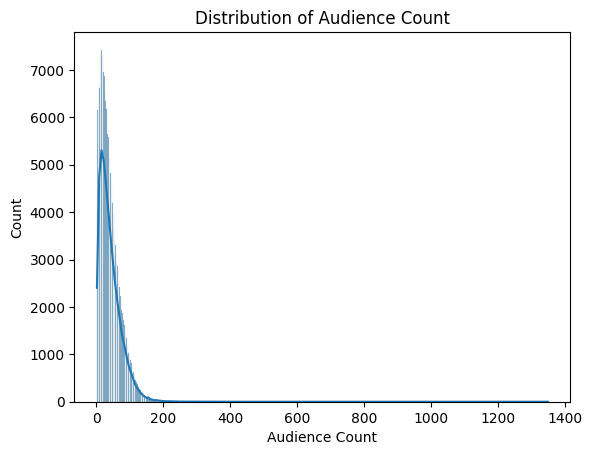

In [10]:
plt.figure()
sns.histplot(train['audience_count'], kde=True)
plt.title("Distribution of Audience Count")
plt.xlabel("Audience Count")
plt.ylabel("Count")
plt.show()

- Understand how audience values are distributed
- Detect skewness left
- Identify unusual patterns

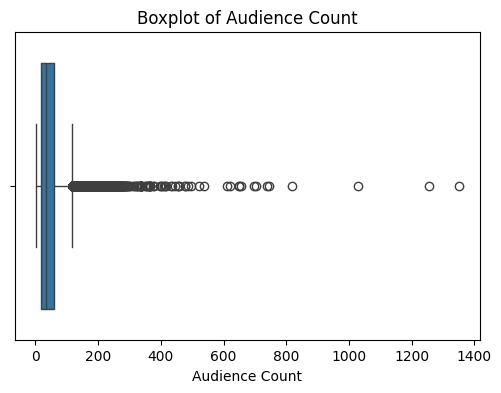

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train['audience_count'])
plt.title("Boxplot of Audience Count")
plt.xlabel('Audience Count')
plt.show()

- Detect outliers
- Understand spread of data
- Identify extreme values

In [12]:
train['audience_count'] = train['audience_count'].apply(
    lambda x: train.loc[train['audience_count'] <= 600, 'audience_count'].max() if x > 600 else x
)

- Capped values above 600
- Replaced extreme values with maximum acceptable value

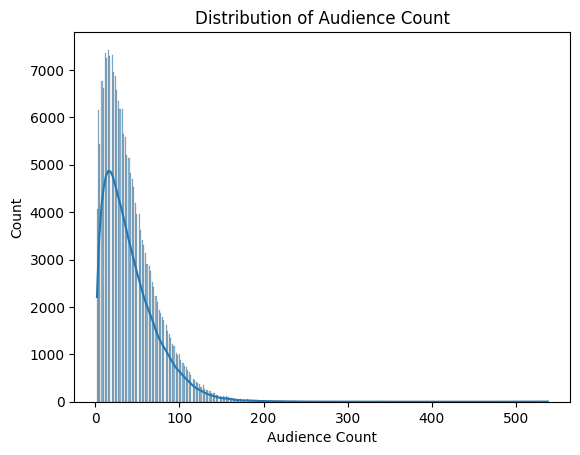

In [13]:
plt.figure()
sns.histplot(train['audience_count'], kde=True)
plt.title("Distribution of Audience Count")
plt.xlabel("Audience Count")
plt.ylabel("Count")
plt.show()

In [14]:
train["show_date"] = pd.to_datetime(train["show_date"])
train = train.sort_values(["book_theater_id", "show_date"])

#### Summary of EDA
- Data is mostly clean
- Some outliers were handled
- Audience distribution analyzed
- Data types corrected
- Identify missing values

## 4. Time Series Analysis

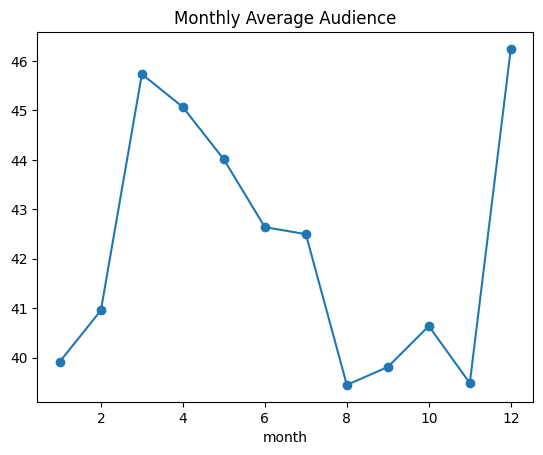

In [15]:
monthly = train.groupby("month")["audience_count"].mean()

monthly.plot(kind="line", marker='o')
plt.title("Monthly Average Audience")
plt.show()

- Helps detect seasonality
- Identifies high-performing periods
- Useful for business planning (movie releases, promotions)

In [16]:
sample_id = train["book_theater_id"].iloc[0]

subset = train[train["book_theater_id"] == sample_id].copy()  

subset = subset.set_index("show_date")

result = seasonal_decompose(
    subset["audience_count"],
    model="additive",
    period=7
) 

In [17]:
trend = result.trend
seasonal = result.seasonal
residual = result.resid
observed = result.observed

In [18]:
decomp_df = pd.DataFrame({
    "observed": observed,
    "trend": trend,
    "seasonality": seasonal,
    "residual": residual
})

decomp_df.head()

,observed,trend,seasonality,residual
show_date,,,,
2023-01-13,50.0,NaN,1.632653,NaN
2023-01-14,64.0,NaN,0.162415,NaN
2023-01-15,58.0,NaN,3.483844,NaN
2023-01-16,44.0,44.000000,2.602891,-2.602891
2023-01-18,12.0,42.857143,-0.897109,-29.960034


We break the data into:
- Trend → long-term movement
- Seasonality → repeating patterns
- Residual → noise/randomness

Why we do this:
- Understand hidden structures in data
- Improve forecasting models

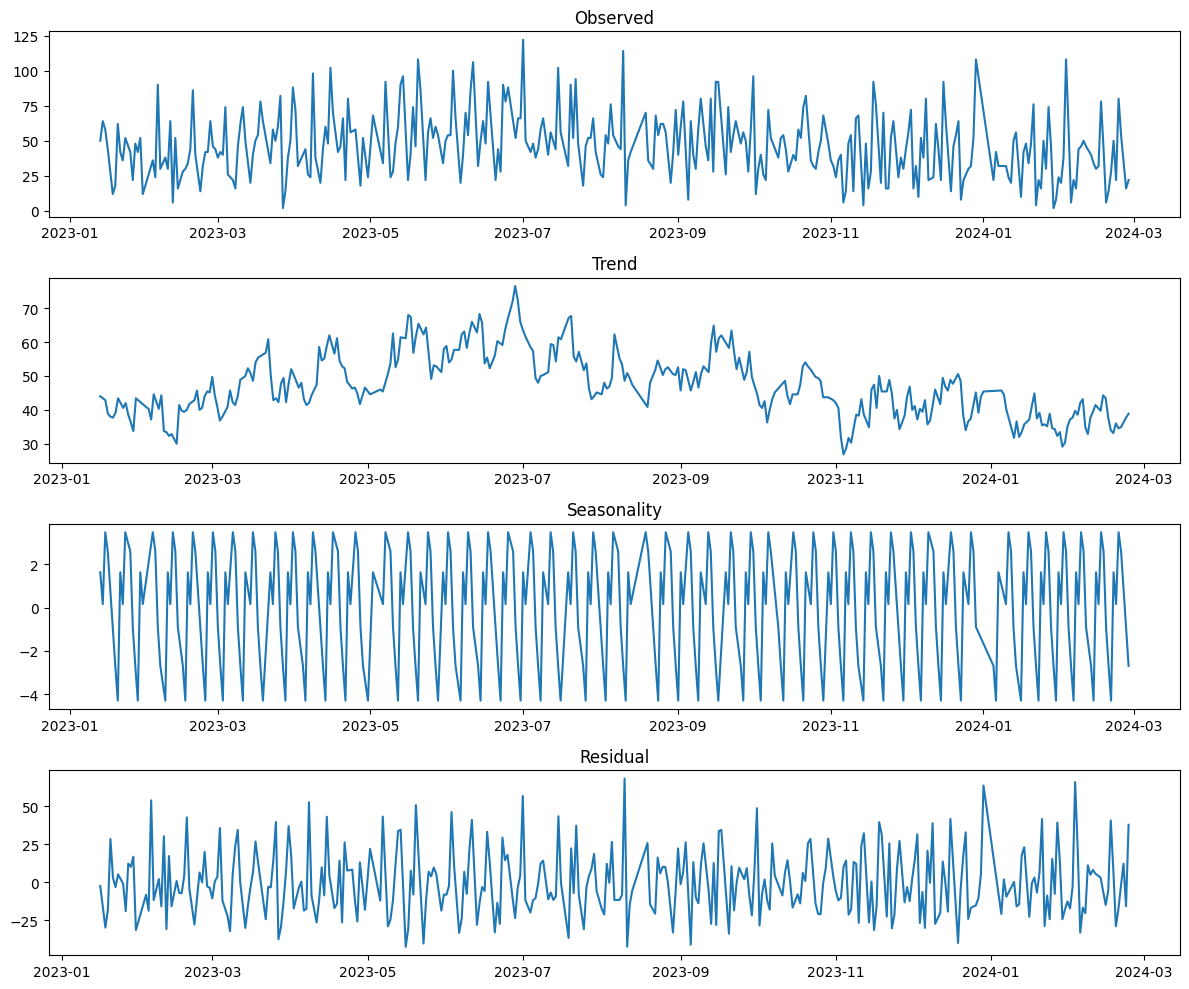

In [19]:
plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(decomp_df.index, decomp_df["observed"])
plt.title("Observed")

plt.subplot(4,1,2)
plt.plot(decomp_df.index, decomp_df["trend"])
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(decomp_df.index, decomp_df["seasonality"])
plt.title("Seasonality")

plt.subplot(4,1,4)
plt.plot(decomp_df.index, decomp_df["residual"])
plt.title("Residual")

plt.tight_layout()
plt.show()

## Time Series Decomposition Analysis

### Overview
The time series has been decomposed into four main components:
- Observed
- Trend
- Seasonality
- Residual

This helps in understanding the underlying patterns in audience behavior.

---

## 1. Observed Data

### What it shows:
The original audience data over time.

### Insights:
- The data shows frequent fluctuations with noticeable spikes and drops.
- There is no perfectly smooth pattern, indicating real-world variability.
- Some extreme peaks suggest special events or high-demand days.

---

## 2. Trend Component

### What it shows:
The overall direction of the data over time.

### Insights:
- The trend increases gradually from early 2023 to mid-2023.
- After mid-year, the trend starts declining.
- This indicates a rise in audience initially, followed by a slowdown.
- Suggests possible seasonal demand or external factors affecting attendance.

---

## 3. Seasonality Component

### What it shows:
Repeating patterns over fixed intervals.

### Insights:
- Strong and consistent cyclical pattern is visible.
- The pattern repeats frequently, likely representing weekly behavior.
- Peaks and dips occur at regular intervals.
- Indicates that audience count is influenced by recurring factors (e.g., weekends vs weekdays).

---

## 4. Residual Component

### What it shows:
Random noise after removing trend and seasonality.

### Insights:
- Residuals are centered around zero but show high variability.
- Some large spikes indicate unexpected events or anomalies.
- The randomness suggests that not all patterns are captured by trend and seasonality.

---

## Key Observations

- The data contains a clear seasonal pattern, likely weekly.
- The trend shows a rise and fall, indicating changing audience interest over time.
- High residual variance suggests external factors influencing audience count.
- The combination of trend and seasonality makes this suitable for time-series modeling.

---

## Conclusion

The decomposition reveals that:
- Audience behavior is driven by both trend and strong seasonality.
- There are irregular fluctuations that cannot be fully explained by patterns alone.
- Feature engineering using lag, rolling statistics, and trend-based features is justified.

This analysis supports the use of advanced models like LightGBM or XGBoost for better prediction.

In [20]:
train["is_peak"] = train["audience_count"] > train["roll_mean_7"] * 1.5

peak_day = train[train["is_peak"]].groupby("dayofweek").size()
peak_day

dayofweek
0     6351
1     2437
2     2899
3     3795
4     3757
5     7259
6    10692
dtype: int64

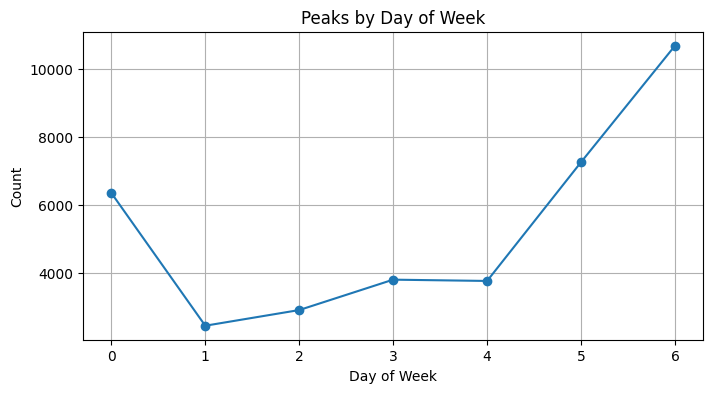

In [21]:
peak_day = train[train["is_peak"]].groupby("dayofweek").size()
peak_day

plt.figure(figsize=(8,4))

plt.plot(peak_day.index, peak_day.values, marker='o')

plt.title("Peaks by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.grid()
plt.show()

In [22]:
train['is_peak'] = train['is_peak'].astype(int)

####  Peak Detection

We define peak days where audience exceeds 1.5× rolling average.

- Identify high-demand days
- Detect unusual spikes
- Useful for business insights and anomaly detection

In [23]:
train["roll_std_7"] = train.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(7).std())
train["roll_std_14"] = train.groupby("book_theater_id")["audience_count"].transform(lambda x: x.rolling(14).std())

###### Create rolling standard deviation features (`roll_std_7`, `roll_std_14`) based on `audience_count`.

Standard deviation measures how much the values vary over time.  
This helps the model understand **volatility** (how stable or unstable the audience is).

In [24]:
train["trend_7"] = train["lag_1"] - train["lag_7"]
train["trend_14"] = train["lag_1"] - train["lag_14"]

# Ratio features
train["lag_ratio_7"] = train["lag_1"] / (train["lag_7"] + 1)

# Difference features
train["diff_1_3"] = train["lag_1"] - train["lag_3"]
train["diff_7_14"] = train["lag_7"] - train["lag_14"]
train["lag3_lag14_diff"] = train["lag_3"] - train["lag_14"]

###### Create new features using existing lag values to capture trends, differences, and relationships in the data.
Lag features represent past values. By combining them, we can help the model understand:
- Trends (increase or decrease over time)
- Differences between time periods
- Relationships between recent and older values

In [25]:
# train.to_csv(r"C:\Users\DELL\OneDrive\Desktop\supervised_project\train.csv", index=False)

In [26]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, LabelEncoder



class ColumnDropper(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors='ignore')


# 1. SIMPLE LABEL ENCODER

class LabelEncoderTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, column):
        self.column = column
        self.encoder = LabelEncoder()

    def fit(self, X, y=None):
        if self.column in X.columns:
            self.encoder.fit(X[self.column].astype(str))
        return self

    def transform(self, X):
        X = X.copy()
        
        if self.column in X.columns:
            X[self.column] = self.encoder.transform(X[self.column].astype(str))
        
        return X


# 2. LAG FEATURE IMPUTER

class LagFeatureImputer(BaseEstimator, TransformerMixin):
    
    def __init__(self, lag_columns):
        self.lag_columns = lag_columns

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()
        
        for col in self.lag_columns:
            if col not in x.columns:
                continue

            lag_n = int(col.split("_")[1])
            values = x[col].values.copy()
            
            i = 0
            while i < len(values):
                
                if pd.isna(values[i]):
                    start = i
                    while i < len(values) and pd.isna(values[i]):
                        i += 1
                    end = i
                    
                    nan_length = end - start
                    
                    next_vals = values[end:end+lag_n]
                    next_vals = next_vals[~pd.isna(next_vals)]
                    
                    if len(next_vals) >= nan_length:
                        for j in range(nan_length):
                            values[start + j] = next_vals[j]
                    else:
                        prev_vals = values[max(0, start-lag_n):start]
                        prev_vals = prev_vals[~pd.isna(prev_vals)]
                        
                        if len(prev_vals) > 0:
                            fill_val = np.mean(prev_vals)
                            values[start:end] = fill_val
                
                else:
                    i += 1
            
            x[col] = values
        
        return x


# 3. ROLLING MEAN IMPUTER

class RollingFeatureImputer(BaseEstimator, TransformerMixin):
    
    def __init__(self, rolling_columns):
        self.rolling_columns = rolling_columns

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()
        
        for col in self.rolling_columns:
            if col in x.columns:
                x[col] = x[col].ffill().bfill()
        
        return x


# 4. DERIVED FEATURE BUILDER

class DerivedFeatureBuilder(BaseEstimator, TransformerMixin):
    
    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()
        
        required_cols = ["lag_1", "lag_3", "lag_7", "lag_14"]
        if not all(col in x.columns for col in required_cols):
            return x
        
        x["trend_7"] = x["lag_1"] - x["lag_7"]
        x["trend_14"] = x["lag_1"] - x["lag_14"]

        x["diff_1_3"] = x["lag_1"] - x["lag_3"]
        x["diff_7_14"] = x["lag_7"] - x["lag_14"]

        x["lag_ratio_7"] = x["lag_1"] / (x["lag_7"] + 1)
        
        return x


# 5. ROLLING STD CREATOR

class RollingStdFeatureCreator(BaseEstimator, TransformerMixin):
    
    def __init__(self, group_col, windows=(7, 14)):
        self.group_col = group_col
        self.windows = windows

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()

        if self.group_col not in x.columns:
            return x

        for window in self.windows:
            col_name = f"roll_std_{window}"
            
            x[col_name] = x.groupby(self.group_col)["lag_1"].transform(
                lambda s: s.rolling(window, min_periods=2).std()
            )

            x[col_name] = x[col_name].fillna(x[col_name].median())

        return x


# 6. FINAL CLEANER

def final_cleaning(x):
    x = x.copy()
    x = x.replace([np.inf, -np.inf], np.nan)
    x = x.fillna(0)
    return x


# 7. COLUMN LISTS

lag_cols = ["lag_1", "lag_3", "lag_7", "lag_14"]
rolling_cols = ["roll_mean_7", "roll_mean_14"]


class DataFrameScaler(StandardScaler):
    
    def fit(self, X, y=None):
        self.columns = X.columns
        return super().fit(X, y)

    def transform(self, X):
        X_scaled = super().transform(X)
        return pd.DataFrame(X_scaled, columns=self.columns, index=X.index)


# 8. FULL PIPELINE

preprocessing_pipeline = Pipeline([
    
    ("label_encode", LabelEncoderTransformer(column="book_theater_id")),
    
    ("lag_imputer", LagFeatureImputer(lag_columns=lag_cols)),
    
    ("rolling_imputer", RollingFeatureImputer(rolling_columns=rolling_cols)),
    
    ("feature_builder", DerivedFeatureBuilder()),
    
    ("rolling_std", RollingStdFeatureCreator(
        group_col="book_theater_id"
    )),
    
    ("final_clean", FunctionTransformer(final_cleaning)),
    
    ("scaler", DataFrameScaler())
])

## Preprocessing Pipeline

### What I do
Build a pipeline to clean data, handle missing values, create features, and scale the dataset.

### Why I do this
To ensure consistent and automated preprocessing before model training.


---

## Steps

### 1. Label Encoding
Convert `book_theater_id` into numeric values so the model can process it.

### 2. Lag Feature Imputation
Fill missing values in lag features using future values or past averages.

### 3. Rolling Feature Imputation
Fill missing values in rolling mean features using forward and backward fill.

### 4. Feature Engineering
Create new features like trends, differences, and ratios from lag values.

### 5. Rolling Standard Deviation
Calculate rolling standard deviation (7 and 14) to capture variability.

### 6. Final Cleaning
Replace infinite values and fill remaining missing values with 0.

### 7. Feature Scaling
Standardize all features to improve model performance.


---

## Pipeline Flow

Data → Encoding → Lag Imputation → Rolling Imputation → Feature Creation → Rolling Std → Cleaning → Scaling


---

## Summary

- Handles missing values  
- Creates meaningful features  
- Captures trends and variability  
- Prepares clean and scaled data  

Final output: Model-ready dataset

In [27]:
# LOAD DATA

def load_data(path):
    
    if path.endswith(".zip"):
        with zipfile.ZipFile(path, 'r') as z:
            file_list = z.namelist()
            
            csv_file = [f for f in file_list if f.endswith(".csv")][0]
            
            with z.open(csv_file) as f:
                df = pd.read_csv(f)
    
    else:
        df = pd.read_csv(path)

    print("Dataset loaded successfully")
    print("Data Shape:", df.shape)

    return df


# SPLIT FEATURES & TARGET

def split_features_target(df, target="audience_count"):
    drop_cols = ["show_date", "book_theater_id"]

    df = df.drop(columns=drop_cols, errors="ignore")

    X = df.drop(columns=[target])
    y = df[target]

    print(" Features & Target separated")
    print("X shape:", X.shape, "| y shape:", y.shape)

    return X, y


# MODEL EVALUATION

def evaluate_model(y_true, y_pred):

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n Model Performance:")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")

    return rmse, mae, r2


# SAVE MODEL

def save_model(model, filename="best_model.pkl"):
    joblib.dump(model, filename)
    print(f"\n Model saved successfully as {filename}")


# LOAD MODEL

def load_model(filename="best_model.pkl"):
    model = joblib.load(filename)
    print(" Model loaded successfully")
    return model

## 1. Load Data

### What I do:
Load dataset from a CSV file or a ZIP file.

### Why I do this:
To make the function flexible so it can handle both normal and compressed data files.

### How it works:
- Check if the file is a `.zip`
- If yes, extract and read the CSV inside it
- If not, directly read the CSV file using pandas
- Print dataset shape for confirmation


## 2. Split Features & Target

### What I do:
Separate the dataset into features (X) and target (y).

### Why I do this:
Machine learning models require input features and a target variable separately.

### How it works:
- Remove unnecessary columns like `show_date` and `book_theater_id`
- Assign remaining columns to X (features)
- Assign `audience_count` to y (target)
- Print shapes for verification


## 3. Model Evaluation

### What I do:
Evaluate model performance using regression metrics.

### Why I do this:
To understand how well the model is predicting values.

### How it works:
- RMSE: measures prediction error magnitude  
- MAE: measures average absolute error  
- R²: shows how well the model explains variance  
- Print all metrics clearly


## 4. Save Model

### What I do:
Save the trained model to a file.

### Why I do this:
To reuse the model later without retraining.

### How it works:
- Use `joblib.dump()` to store the model
- Save it as a `.pkl` file
- Print confirmation message


## 5. Load Model

### What I do:
Load a previously saved model.

### Why I do this:
To use the trained model for predictions without training again.

### How it works:
- Use `joblib.load()` to read the file
- Return the loaded model
- Print confirmation message

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from utils import load_data, split_features_target, evaluate_model, save_model
from preprocessing import preprocessing_pipeline, ColumnDropper

df = load_data("train.zip")
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "LightGBM": LGBMRegressor(),
    "XGBoost": XGBRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

best_score = -1
best_pipe = None
best_name = ""

results_list = []

for name, model in models.items():

    print(f"\n Training {name}...")

    pipe = Pipeline([
        ("drop_id", ColumnDropper(columns=["book_theater_id"])),
        ("preprocessor", preprocessing_pipeline),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse, mae, r2 = evaluate_model(y_test, y_pred)

    results_list.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    if r2 > best_score:
        best_score = r2
        best_pipe = pipe
        best_name = name

results_df = pd.DataFrame(results_list)

print("\n All Model Results:")
print(results_df.sort_values(by="R2", ascending=False))

print(f"\n Best Model: {best_name} | R2 Score: {best_score:.4f}")

final_model = best_pipe.named_steps["model"]

X_processed = best_pipe[:-1].transform(X_train)

preprocessor = best_pipe.named_steps["preprocessor"]

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = X_train.columns

feature_names = np.array(feature_names)

if hasattr(final_model, "feature_importances_"):

    importance_score = final_model.feature_importances_

    min_len = min(len(feature_names), len(importance_score))
    feature_names = feature_names[:min_len]
    importance_score = importance_score[:min_len]

    indices = np.argsort(importance_score)[::-1]

    plt.figure(figsize=(12, 6))
    plt.title(f"{best_name} Feature Importance")

    plt.bar(range(min_len), importance_score[indices])
    plt.xticks(range(min_len), feature_names[indices], rotation=90)

    plt.tight_layout()
    plt.show()

else:
    print(f"{best_name} does not support feature_importances_")

print("\n Starting LightGBM Hyperparameter Tuning...")

lgbm_pipeline = Pipeline([
    ("drop_id", ColumnDropper(columns=["book_theater_id"])),
    ("preprocessor", preprocessing_pipeline),
    ("model", LGBMRegressor(random_state=42))
])

param_random = {
    "model__num_leaves": [31, 50, 100],
    "model__max_depth": [-1, 5, 10, 20],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [100, 200, 500],
    "model__min_data_in_leaf": [10, 20, 50],
    "model__lambda_l1": [0.0, 0.1, 1.0],
    "model__lambda_l2": [0.0, 1.0, 5.0],
    "model__feature_fraction": [0.6, 0.8, 1.0],
    "model__bagging_fraction": [0.6, 0.8, 1.0],
    "model__bagging_freq": [0, 5],
    "model__max_bin": [255, 512],
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_random,
    n_iter=30,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\n Best Parameters:")
print(random_search.best_params_)

print("\n Best CV Score (RMSE):", random_search.best_score_)

print("\n===== Final LightGBM Performance =====")

y_pred = best_model.predict(X_test)

rmse, mae, r2 = evaluate_model(y_test, y_pred)

save_model(best_model, "best_model.pkl") 

Dataset loaded successfully
Data Shape: (214046, 26)
 Features & Target separated
X shape: (214046, 23) | y shape: (214046,)

 Training LinearRegression...


## Model Training and Selection

### What I do
Train multiple machine learning models, evaluate their performance, and select the best one.

### Why I do this
Different models perform differently on data, so comparing them helps identify the most accurate model.


---

## Steps

### 1. Data Loading and Splitting
Load the dataset and split it into training and testing sets to evaluate model performance on unseen data.

### 2. Model Definition
Define multiple models:
- Linear Regression  
- Decision Tree  
- Random Forest  
- LightGBM  
- XGBoost  
- Gradient Boosting  

### 3. Training and Evaluation
- Create a pipeline (column dropping + preprocessing + model)
- Train each model on training data  
- Predict on test data  
- Evaluate using RMSE, MAE, and R²  
- Store results for comparison  

### 4. Best Model Selection
Select the model with the highest R² score and keep its pipeline for further use.

### 5. Model Comparison
Store all model results in a DataFrame and sort them based on performance.


---

## Feature Importance

### What I do
Visualize feature importance of the best model (if supported).

### Why I do this
To understand which features contribute most to predictions.

### How it works
- Extract feature names from preprocessing  
- Get importance scores from the model  
- Plot a bar chart for visualization  


---

## LightGBM Hyperparameter Tuning

### What I do
Tune the LightGBM model using RandomizedSearchCV.

### Why I do this
To improve model performance by finding optimal parameters.

### How it works
- Define parameter search space  
- Use TimeSeriesSplit for cross-validation  
- Run random search with multiple parameter combinations  
- Select best model based on RMSE  


---

## Final Model Evaluation

### What I do
Evaluate the tuned LightGBM model on test data.

### Why I do this
To measure final model performance after tuning.

### How it works
- Predict using test data  
- Calculate RMSE, MAE, and R²  


---

## Model Saving

### What I do
Save the final trained model.

### Why I do this
To reuse the model later without retraining.

### How it works
Store the model as `best_model.pkl` using joblib.


---

## Summary

- Compared multiple models  
- Selected best based on performance  
- Analyzed feature importance  
- Tuned LightGBM for improvement  
- Evaluated final model  
- Saved model for future use  

Final output: Optimized and production-ready model